<a href="https://colab.research.google.com/github/sadhub10/SIC-2025-Aulas-Pa09-y-Pa10/blob/main/Clase%202%20-%20IA%20-%20Capitulo%208%20-%20Unidad%202%20-%2024/11/2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚙️ UNIDAD 2: Fundamentos de TensorFlow (120 min)

**Objetivo:** Adquirir competencia práctica con la biblioteca TensorFlow, la unidad fundamental de datos (Tensors) y la interfaz de alto nivel Keras para el Deep Learning.

---

## I. Introducción y la Estructura de Datos (Min. 0-30)

### 1.1. TensorFlow 2.x y Keras

**Teoría:** TensorFlow es la plataforma de código abierto para construir y entrenar modelos de IA. Su versión moderna (TF 2.x) se basa en la **Eager Execution** (Ejecución Eager), que permite un desarrollo de código similar al Python tradicional, sin necesidad de definir gráficos estáticos.

**Analogía del Taller:** TensorFlow es el **"Taller de Ingeniería"** donde se ensamblan y prueban las redes neuronales. Keras es el **"Tablero de Control"** amigable que facilita el trabajo al desarrollador.

In [ ]:
import tensorflow as tf

print(f"Versión de TensorFlow instalada: {tf.__version__}")
print(f"Eager Execution está activa: {tf.executing_eagerly()}")

Versión de TensorFlow instalada: 2.19.0
Eager Execution está activa: True


### 1.2. Los Tensors: La Unidad Fundamental

**Concepto:** Un **Tensor** es la estructura de datos principal de TensorFlow, esencialmente un array multidimensional. Es la forma en que la red representa todos los datos, desde las imágenes hasta los pesos internos.

**Analogía de los Ladrillos Lego:** Cada tensor es un ladrillo Lego con tres propiedades clave:
1.  **Rank (Dimensión):** ¿Cuántos ejes tiene? (Ej. escalar=0, vector=1, matriz=2).
2.  **Shape (Forma):** ¿Cuántos elementos hay en cada eje? (Ej. 3x5).
3.  **Dtype (Tipo de Dato):** ¿Qué contienen los elementos? (Ej. float32, int64).

---

## 🛠️ Métodos y Funciones Aplicables de TensorFlow (Unidad 2)
I. Creación de Tensors y Variables

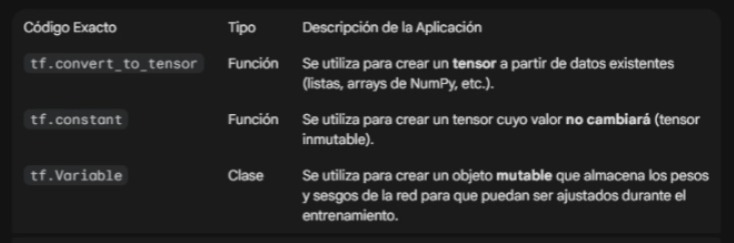

## II. Creación y Manipulación de Tensors (Min. 30-60)

### 2.1. Código 1: Creación Básica de Tensors Constantes

Usamos `tf.constant()` para crear datos fijos. Demostramos Tensors de Rank 0, 1 y 2.

In [ ]:
# Tensor Escalar (Rank 0)
escalar = tf.constant(42.0)
print(f"Escalar: {escalar}\nRank: {escalar.ndim}\nShape: {escalar.shape}\n")

# Tensor Vector (Rank 1)
vector = tf.constant([1.5, 3.0, 4.5, 6.0], dtype=tf.float32)
print(f"Vector: {vector}\nRank: {vector.ndim}\nShape: {vector.shape}\n")

# Tensor Matriz (Rank 2)
matriz = tf.constant([ [1, 2, 3], [4, 5, 6] ])
print(f"Matriz: {matriz}\nRank: {matriz.ndim}\nShape: {matriz.shape}\n")

Escalar: 42.0
Rank: 0
Shape: ()

Vector: [1.5 3.  4.5 6. ]
Rank: 1
Shape: (4,)

Matriz: [[1 2 3]
 [4 5 6]]
Rank: 2
Shape: (2, 3)



II. Operaciones Matemáticas y de Conjunto de Datos

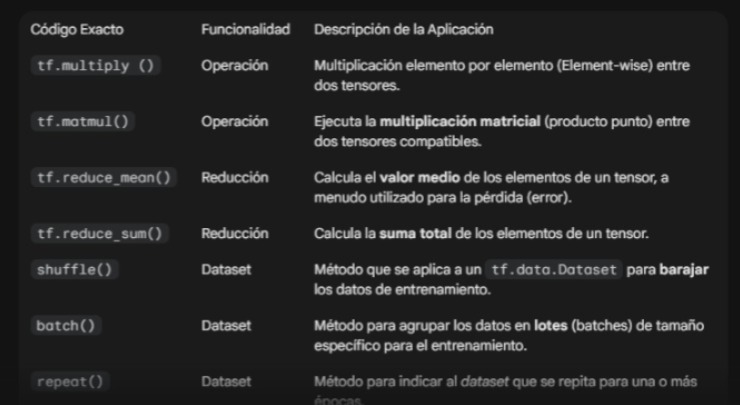

### 2.2. Código 2: Operaciones Aritméticas

TensorFlow optimiza las operaciones con Tensors para ejecutarse rápidamente en la GPU/TPU (si está disponible). Demostramos operaciones element-wise y la multiplicación matricial.

In [ ]:
A = tf.constant([[1, 2], [3, 4]])
B = tf.constant([[5, 6], [7, 8]])

# Operación Element-wise (Multiplicación elemento por elemento)
mult_elemento = tf.multiply(A, B)
print(f"Multiplicación Element-wise:\n{mult_elemento}\n")

# Operación Matricial (Multiplicación de matrices)
# (2x2) @ (2x2) = (2x2)
mult_matriz = tf.matmul(A, B)
print(f"Multiplicación Matricial (tf.matmul):\n{mult_matriz}\n")

# Broadcasting (Suma de un escalar a una matriz)
broadcasting = A + 10
print(f"Broadcasting (A + 10):\n{broadcasting}")

Multiplicación Element-wise:
[[ 5 12]
 [21 32]]

Multiplicación Matricial (tf.matmul):
[[19 22]
 [43 50]]

Broadcasting (A + 10):
[[11 12]
 [13 14]]


---

## III. Variables y el Aprendizaje (Min. 60-90)

### 3.1. Constantes vs. Variables

**Concepto:** Las **Variables** (`tf.Variable`) son Tensors cuyo valor puede cambiar. En el contexto de las redes neuronales, las variables representan los **pesos** y **sesgos** (los parámetros que el modelo ajusta durante el entrenamiento).

**Analogía del Piloto:** La **Constante** es la **carretera** (datos inmutables). La **Variable** es el **volante** y el **pedal** (parámetros que el piloto, es decir, el optimizador, ajusta constantemente para minimizar el error).

In [ ]:
peso = tf.Variable(0.0, name="peso_inicial")
print(f"Valor inicial del peso: {peso.numpy()}")

# Podemos cambiar el valor de una Variable usando .assign()
peso.assign(peso + 0.5)
print(f"Nuevo valor del peso después de un ajuste: {peso.numpy()}")

Valor inicial del peso: 0.0
Nuevo valor del peso después de un ajuste: 0.5


### 3.2. Código 3: La Cinta de Gradientes (tf.GradientTape)

**Teoría:** `tf.GradientTape` es un contexto especial que **graba** todas las operaciones que se ejecutan sobre las `tf.Variable` para poder calcular las derivadas después. ¡Este es el mecanismo que implementa la **Retropropagación**!

**Ejemplo Práctico:** Calcularemos la derivada de $y = x^2$ en $x=3$. La derivada debe ser $2x = 6$.

In [ ]:
x = tf.Variable(3.0) # Queremos calcular el gradiente con respecto a esta variable

with tf.GradientTape() as tape:
    # Registramos la operación: y = x^2
    y = x * x

# Pedimos a la 'cinta' que calcule el gradiente de y con respecto a x
gradiente = tape.gradient(y, x)

print(f"Función: y = x^2")
print(f"Valor de x: {x.numpy()}")
print(f"El gradiente (dy/dx) en x=3 es: {gradiente.numpy()} (esperábamos 6.0)")

Función: y = x^2
Valor de x: 3.0
El gradiente (dy/dx) en x=3 es: 6.0 (esperábamos 6.0)


---

## IV. Keras en Acción: Modelado Sencillo (Min. 90-120)

### 4.1. Código 4: Definición de un Modelo Lineal

Usaremos la API `Sequential` de Keras, que permite apilar capas de forma simple. Crearemos el equivalente a un Perceptrón (1 capa densa).

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Definir el modelo (secuencia de capas)
modelo_lineal = Sequential([
    # Una capa densa con 1 neurona, esperando 1 característica de entrada (input_shape)
    Dense(units=1, input_shape=[1])
])

modelo_lineal.summary()

# El modelo tiene 2 parámetros: 1 peso (W) y 1 sesgo (b).

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

### III. Optimizadores (Aprendizaje y Retropropagación)

Estas son las clases de optimizadores mencionadas en la presentación para aplicar el Descenso de Gradiente (aunque en la versión moderna de TF se accede via tf.keras.optimizers).


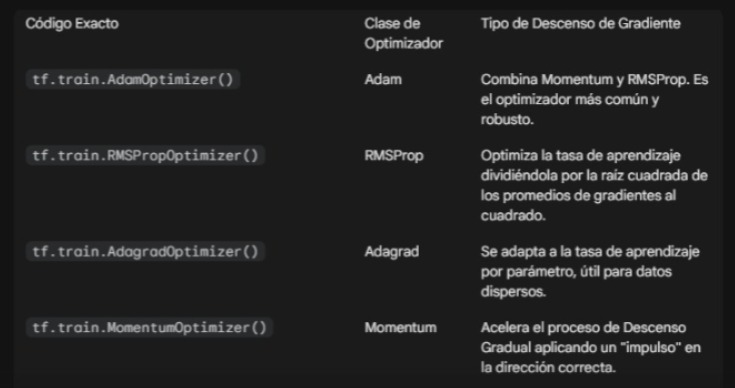

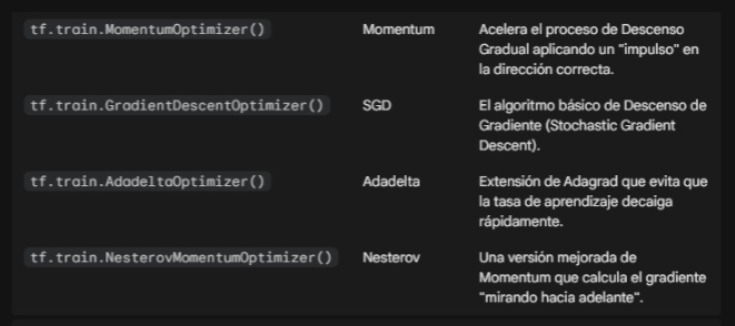

### 4.2. Código 5: Compilación y Entrenamiento Mínimo

Conectamos la teoría de la Unidad 1 con la práctica:
* **Optimizador:** Implementa el Descenso de Gradiente (usamos `sgd`).
* **Pérdida (*Loss*):** La función de costo que medimos (`mse`).

Entrenaremos un modelo simple que aproxima la función $y = 2x - 1$.

In [ ]:
import numpy as np

# 1. Crear datos de ejemplo (y = 2x - 1 + ruido)
X = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=float)
Y = np.array([-3.0, -1.0, 1.0, 3.0, 5.0, 7.0], dtype=float)

# 2. Compilar el modelo
modelo_lineal.compile(
    optimizer='sgd',
    loss='mse' # Mean Squared Error (Error cuadrático medio)
)

# 3. Entrenar el modelo (Ajustar los pesos W y b)
print("\n--- Iniciando Entrenamiento (100 Épocas) ---")
historia = modelo_lineal.fit(X, Y, epochs=100, verbose=0)

# 4. Realizar una Predicción
prediccion = modelo_lineal.predict(np.array([10.0]))[0][0]
print(f"\nPredicción para X=10.0 (esperado 19.0): {round(prediccion, 2)}")
print("\n¡Los pesos se ajustaron automáticamente usando TensorFlow/Keras!")


--- Iniciando Entrenamiento (100 Épocas) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Predicción para X=10.0 (esperado 19.0): 18.18000030517578

¡Los pesos se ajustaron automáticamente usando TensorFlow/Keras!


---

## V. Cierre y Transición

**Resumen de la Unidad 2:**
Hemos pasado de la teoría abstracta al código funcional.
* **Tensor:** Unidad de datos.
* **Variable:** Parámetro que aprende (peso/sesgo).
* **GradientTape:** Mecanismo de retropropagación.
* **Keras:** API de alto nivel para definir, compilar y entrenar modelos.

**Próximo Paso:** En la **Unidad 3**, aplicaremos estos fundamentos para construir y entrenar modelos complejos: Redes Neuronales Profundas (DNN), Redes Convolucionales (CNN) y Redes Recurrentes (RNN).

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout
import numpy as np

# --- 1. Definición de Parámetros ---
# Forma de entrada: 28x28 píxeles con 1 canal (escala de grises, como MNIST)
INPUT_SHAPE = (28, 28, 1)
NUM_CLASSES = 10

# --- 2. Creación del Modelo CNN ---
modelo_cnn = Sequential([
    # Capa 1: Convolución
    # 32 filtros, tamaño 3x3, función de activación ReLU
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=INPUT_SHAPE),

    # Capa 2: Agrupación (Pooling)
    # Reduce el tamaño de la imagen a la mitad (2x2)
    MaxPooling2D(pool_size=(2, 2)),

    # Capa 3: Dropout
    # Desactiva el 25% de las neuronas para evitar el sobreajuste (overfitting)
    Dropout(0.25),

    # Capa 4: Aplanamiento
    # Convierte la salida 2D del pooling en un vector 1D para alimentar la capa densa
    Flatten(),

    # Capa 5: Densa (Clasificación)
    # 128 neuronas densas
    Dense(128, activation='relu'),

    # Capa 6: Salida
    # 10 salidas (para 10 clases), con activación Softmax para probabilidades
    Dense(NUM_CLASSES, activation='softmax')
])

# --- 3. Resumen y Compilación ---
print("--- Resumen de la Arquitectura CNN ---")
modelo_cnn.summary()

# El modelo se compilaría antes de entrenar:
# modelo_cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

--- Resumen de la Arquitectura CNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Esta arquitectura es una Red Neuronal Convolucional (CNN) clásica para clasificación de imágenes, como la que se usa para el conjunto de datos MNIST. Cada capa cumple una función específica e indispensable en el proceso de extracción de características y clasificación.

## **1. Capas de Extracción de Características**
Estas capas son las que "miran" la imagen y aprenden patrones, bordes, texturas y otras características importantes.

### Capa 1:Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=INPUT_SHAPE)

* Función Principal: Realizar la Convolución . Aplica 32 pequeños filtros (kernels) de$3 \times 3$píxeles sobre la imagen de entrada. Cada filtro aprende a reconocer un patrón diferente (ej. una línea horizontal, una esquina).

* 32(Filtros): El número de mapas de características (o filtros) que la capa aprenderá. La salida tendrá una profundidad de 32.

* kernel_size=(3, 3): El tamaño de la ventana de filtro que se desliza sobre la imagen.

* activation='relu': La función de activación Unidad Lineal Rectificada . Introduce la no-linealidad , permitiendo que la red aprenda relaciones complejas.

### Capa 2:MaxPooling2D(pool_size=(2, 2))
* Función Principal: Reducir la Dimensionalidad Espacial y hacer el modelo más robusto a las pequeñas traslaciones o distorsiones de la imagen (invariancia a la traslación).
* pool_size=(2, 2): La ventana de$2 \times 2$se desliza sobre el mapa de características y conserva solo el valor máximo dentro de esa ventana. Esto reduce a la mitad tanto la altura como la anchura de la imagen (ej. si la entrada es$28 \times 28$, la salida será$14 \times 14$).

### Capa 3:Dropout(0.25)
* Función Principal: Regularización para prevenir el sobreajuste (overfitting) .
* 0.25: Indica que el 25% de las neuronas de la capa anterior se "apagan" aleatoriamente durante cada paso de entrenamiento. Esto obliga a la red a no depender demasiado de ninguna neurona específica, mejorando su capacidad de generalización en datos nuevos.

## **2. Capas de Clasificación**
Estas capas toman las características extraídas y las utilizan para producir la predicción final.

### Capa 4:Flatten()
* Función Principal: Transformación de Forma . Es una capa de transición.

* Toma la salida 3D (alto, ancho, profundidad/canales) de las capas convolucionales y la convierte en un vector 1D (una fila larga de números). Esto es necesario porque las capas densas ( Dense) solo aceptan datos de entrada unidimensionales.

### Capa 5:Dense(128, activation='relu')
* Función Principal: Clasificación y Aprendizaje de Alto Nivel . Es una capa de perceptrón multicapa completamente conectada.

* Cada una de las 128 neuronas recibe la entrada de todas las neuronas de la capa anterior ( Flatten). Aquí es donde la red combina las características de bajo nivel (detectadas por Conv2D) para tomar decisiones de clasificación más complejas.

### Capa 6:Dense(NUM_CLASSES, activation='softmax')
* Función Principal: Capa de Salida y predicción de Probabilidades .

+ NUM_CLASSES(10): Tiene 10 neuronas , una para cada dígito posible (0 a 9).

* activation='softmax': Convierte los valores de salida de las 10 neuronas en una distribución de probabilidad . La suma de las 10 salidas siempre será 1.0, y el valor más alto es la predicción del modelo (por ejemplo, 0.95 para el dígito "4").

### **💻 Resumen de la Arquitectura**
La arquitectura opera en tres fases:

* Observación (Conv2D): Aprende qué partes de la imagen son importantes.

* Compresión y Regularización (MaxPooling2D & Dropout): Reduce la cantidad de datos innecesarios y previene el sobreajuste.

* Decisión (Flatten & Dense): Toma el conjunto final de características comprimidas y mezcladas para calcular la probabilidad de que la imagen pertenezca a cada una de las 10 categorías.